# Phase 2: Model Training & Evaluation

## Setup — Load Preprocessed Data from Phase 1

In [26]:
# ============================================================
# Install dependencies & restart runtime
# Run this cell, then go to Runtime > Restart session
# ============================================================
!pip install datasets==2.14.7 huggingface_hub==0.21.4 transformers==4.40.2 -q
!pip install underthesea scikit-learn -q
!pip install mlflow -q
print("✅ Done. Now go to Runtime > Restart session, then run the next cell.")

✅ Done. Now go to Runtime > Restart session, then run the next cell.


In [27]:
# ============================================================
# Import libraries and mount Google Drive
# Load preprocessed CSVs saved at the end of Phase 1
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import os
import json
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, accuracy_score, f1_score
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

DATA_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis/data'
train_df = pd.read_csv(f'{DATA_DIR}/train_preprocessed.csv')
val_df = pd.read_csv(f'{DATA_DIR}/val_preprocessed.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test_preprocessed.csv')

print(f"Loaded — Train: {len(train_df):,}, Val: {len(val_df):,}, Test: {len(test_df):,}")

# MLflow setup
import mlflow
import mlflow.pytorch

MLFLOW_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis/mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('vietnamese-sentiment-analysis')
print(f"MLflow tracking: {MLFLOW_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Loaded — Train: 11,426, Val: 1,583, Test: 3,166
MLflow tracking: /content/drive/MyDrive/phobert-sentiment-analysis/mlruns


In [28]:
# ============================================================
# Rebuild tokenizer, Dataset class, and DataLoaders
# Same config as Phase 1 — MAX_LENGTH=128, BATCH_SIZE=32
# ============================================================
LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']
NUM_CLASSES = 3
MAX_LENGTH = 128
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

class VietnameseSentimentDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe['clean_text'].tolist()
        self.labels = dataframe['sentiment'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = VietnameseSentimentDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = VietnameseSentimentDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = VietnameseSentimentDataset(test_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"DataLoaders ready — Train: {len(train_loader)} batches, Val: {len(val_loader)}, Test: {len(test_loader)}")

DataLoaders ready — Train: 358 batches, Val: 50, Test: 99


## 2.1 Baseline — TF-IDF + Logistic Regression

In [29]:
# ============================================================
# Baseline: TF-IDF + Logistic Regression — tracked with MLflow
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

with mlflow.start_run(run_name="tfidf-logreg-baseline"):
    mlflow.log_param("model_type", "TF-IDF + LogReg")
    mlflow.log_param("max_features", 20000)
    mlflow.log_param("ngram_range", "(1, 2)")
    mlflow.log_param("C", 1.0)

    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
    X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
    X_val_tfidf = tfidf.transform(val_df['clean_text'])
    X_test_tfidf = tfidf.transform(test_df['clean_text'])

    lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    lr_model.fit(X_train_tfidf, train_df['sentiment'])

    y_val_pred = lr_model.predict(X_val_tfidf)
    y_test_pred = lr_model.predict(X_test_tfidf)

    val_acc = accuracy_score(val_df['sentiment'], y_val_pred)
    test_acc = accuracy_score(test_df['sentiment'], y_test_pred)
    test_f1 = f1_score(test_df['sentiment'], y_test_pred, average='macro')

    mlflow.log_metric("val_accuracy", val_acc)
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_f1_macro", test_f1)

    print("=== Baseline — Validation Set ===")
    print(f"Accuracy: {val_acc:.4f}")
    print(classification_report(val_df['sentiment'], y_val_pred, target_names=LABEL_NAMES))

    print("=== Baseline — Test Set ===")
    print(f"Accuracy: {test_acc:.4f}")
    print(classification_report(test_df['sentiment'], y_test_pred, target_names=LABEL_NAMES))

=== Baseline — Validation Set ===
Accuracy: 0.9097
              precision    recall  f1-score   support

    Negative       0.88      0.96      0.92       705
     Neutral       0.86      0.08      0.15        73
    Positive       0.93      0.94      0.94       805

    accuracy                           0.91      1583
   macro avg       0.89      0.66      0.67      1583
weighted avg       0.91      0.91      0.89      1583

=== Baseline — Test Set ===
Accuracy: 0.8904
              precision    recall  f1-score   support

    Negative       0.86      0.97      0.91      1409
     Neutral       0.71      0.06      0.11       167
    Positive       0.93      0.91      0.92      1590

    accuracy                           0.89      3166
   macro avg       0.83      0.65      0.65      3166
weighted avg       0.88      0.89      0.87      3166



In [30]:
# ============================================================
# Store baseline results for later comparison (Phase 3)
# ============================================================
results = {
    'model': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'test_f1_macro': []
}

results['model'].append('TF-IDF + LogReg')
results['val_accuracy'].append(accuracy_score(val_df['sentiment'], y_val_pred))
results['test_accuracy'].append(accuracy_score(test_df['sentiment'], y_test_pred))
results['test_f1_macro'].append(f1_score(test_df['sentiment'], y_test_pred, average='macro'))

## 2.2 PhoBERT Fine-Tuning

In [31]:
# ============================================================
# Load PhoBERT with a 3-class classification head
# ============================================================
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/phobert-base',
    num_labels=NUM_CLASSES
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Device: {device}")
print(f"Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device: cuda
Total parameters:     135,000,579
Trainable parameters: 135,000,579


In [32]:
# ============================================================
# Optimizer and learning rate scheduler
# AdamW with linear warmup prevents early training instability
# ============================================================
from transformers import get_linear_schedule_with_warmup

EPOCHS = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Epochs: {EPOCHS}, Total steps: {total_steps}, Warmup steps: {warmup_steps}")

Epochs: 4, Total steps: 1432, Warmup steps: 143


In [33]:
# ============================================================
# Training and evaluation helper functions
# Separated for clarity and reuse in the training loop
# ============================================================
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)

In [36]:
# ============================================================
# Training loop with early stopping — tracked with MLflow
# ============================================================
CHECKPOINT_DIR = '/content/drive/MyDrive/phobert-sentiment-analysis/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

with mlflow.start_run(run_name="phobert-finetune"):
    mlflow.log_param("model_name", "vinai/phobert-base")
    mlflow.log_param("max_length", MAX_LENGTH)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("warmup_ratio", WARMUP_RATIO)
    mlflow.log_param("weight_decay", 0.01)
    mlflow.log_param("patience", 2)

    best_val_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print(f"{'='*50}")

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_acc", train_acc, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_acc", val_acc, step=epoch)
        mlflow.log_metric("val_f1", val_f1, step=epoch)

        print(f"Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
        print(f"Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience = 2
            patience_counter = 0
            model.save_pretrained(CHECKPOINT_DIR)
            tokenizer.save_pretrained(CHECKPOINT_DIR)
            print(f">>> Best model saved! F1: {best_val_f1:.4f}")
        else:
            patience_counter += 1
            print(f">>> No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    mlflow.log_metric("best_val_f1", best_val_f1)
    mlflow.log_metric("stopped_at_epoch", len(history['train_loss']))

    print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")


Epoch 1/4


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Train — Loss: 0.1894, Acc: 0.9441
Val   — Loss: 0.1981, Acc: 0.9438, F1: 0.8176
>>> Best model saved! F1: 0.8176

Epoch 2/4


Training:   0%|          | 0/358 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Train — Loss: 0.1117, Acc: 0.9724
Val   — Loss: 0.1901, Acc: 0.9558, F1: 0.8753
>>> Best model saved! F1: 0.8753

Epoch 4/4


Training:   0%|          | 0/358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Train — Loss: 0.0876, Acc: 0.9771
Val   — Loss: 0.1955, Acc: 0.9520, F1: 0.8644
>>> No improvement. Patience: 1/2

Training complete. Best val F1: 0.8753


## 2.3 Test Set Evaluation

In [37]:
# ============================================================
# Load best checkpoint and evaluate on held-out test set
# ============================================================
best_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_DIR)
best_model.to(device)

test_loader_eval = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(best_model, test_loader_eval, device)

print("=== PhoBERT — Test Set ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Macro: {test_f1:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=LABEL_NAMES))

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

=== PhoBERT — Test Set ===
Accuracy: 0.9394
F1 Macro: 0.8280

              precision    recall  f1-score   support

    Negative       0.94      0.97      0.96      1409
     Neutral       0.71      0.48      0.57       167
    Positive       0.95      0.96      0.96      1590

    accuracy                           0.94      3166
   macro avg       0.87      0.80      0.83      3166
weighted avg       0.94      0.94      0.94      3166



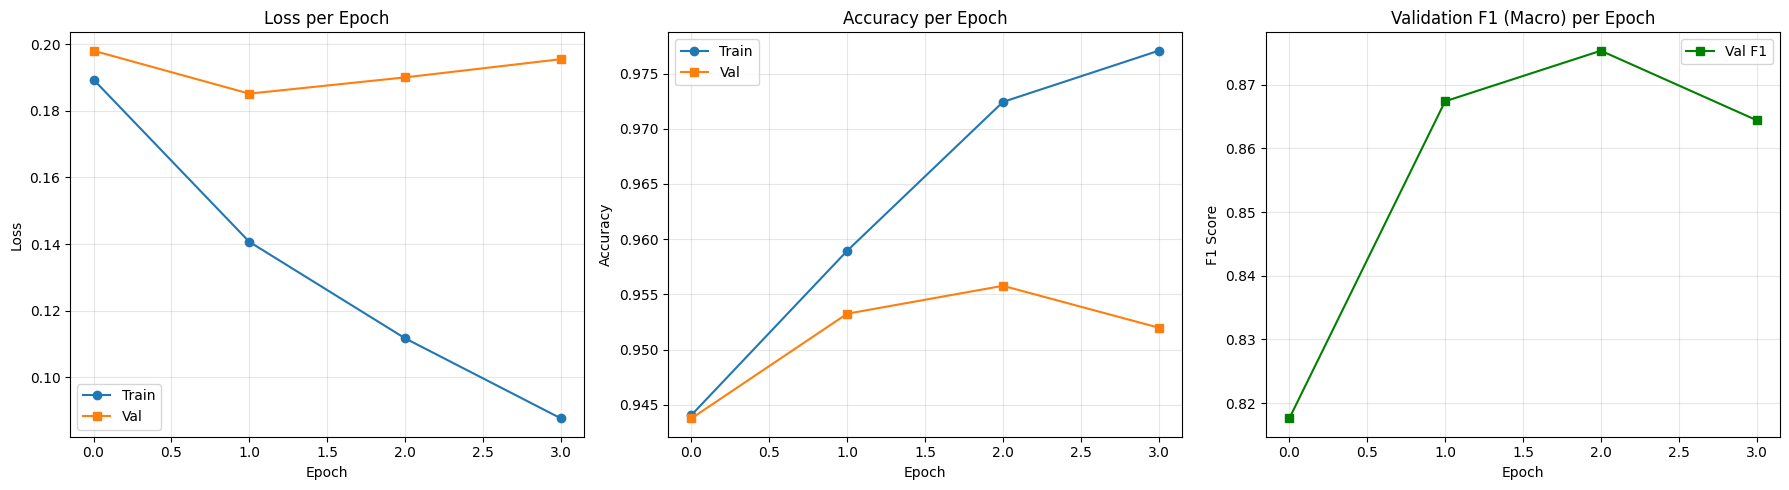

In [38]:
# ============================================================
# Training curves — track overfitting and convergence
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], 'o-', label='Train')
axes[0].plot(history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], 'o-', label='Train')
axes[1].plot(history['val_acc'], 's-', label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_f1'], 's-', label='Val F1', color='green')
axes[2].set_title('Validation F1 (Macro) per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phobert-sentiment-analysis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

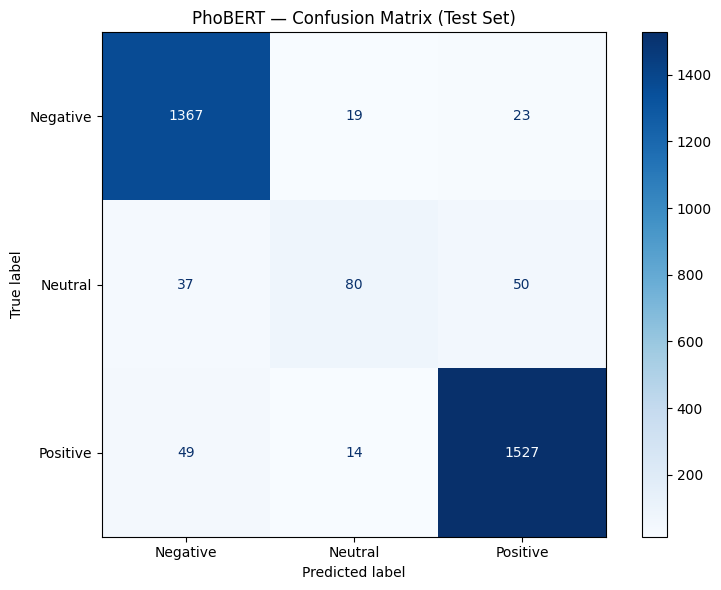


Per-class accuracy:
  Negative: 0.9702 (1367/1409)
  Neutral: 0.4790 (80/167)
  Positive: 0.9604 (1527/1590)


In [39]:
# ============================================================
# Confusion matrix — reveals which classes the model confuses
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('PhoBERT — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/phobert-sentiment-analysis/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class accuracy:")
for i, label in enumerate(LABEL_NAMES):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"  {label}: {class_acc:.4f} ({cm[i, i]}/{cm[i].sum()})")

In [40]:
# ============================================================
# Update results table — baseline vs PhoBERT side by side
# ============================================================
results['model'].append('PhoBERT (fine-tuned)')
results['val_accuracy'].append(max(history['val_acc']))
results['test_accuracy'].append(test_acc)
results['test_f1_macro'].append(test_f1)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

               model  val_accuracy  test_accuracy  test_f1_macro
     TF-IDF + LogReg      0.909665       0.890398       0.645653
PhoBERT (fine-tuned)      0.955780       0.939356       0.828024


In [41]:
# ============================================================
# Save training history and results for Phase 3 analysis
# ============================================================
import json

artifacts_dir = '/content/drive/MyDrive/phobert-sentiment-analysis'

with open(f'{artifacts_dir}/training_history.json', 'w') as f:
    json.dump(history, f)

results_df.to_csv(f'{artifacts_dir}/model_results.csv', index=False)

# Save test predictions for error analysis in Phase 3
test_df['phobert_pred'] = test_preds
test_df.to_csv(f'{artifacts_dir}/data/test_with_predictions.csv', index=False)

print("Saved: training_history.json, model_results.csv, test_with_predictions.csv")

Saved: training_history.json, model_results.csv, test_with_predictions.csv


In [42]:
# ============================================================
# View all MLflow experiment runs in one table
# ============================================================
experiment = mlflow.get_experiment_by_name('vietnamese-sentiment-analysis')
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

display_cols = [c for c in [
    'run_name', 'params.model_type', 'params.model_name',
    'params.learning_rate', 'metrics.val_accuracy',
    'metrics.test_accuracy', 'metrics.test_f1_macro', 'metrics.best_val_f1'
] if c in runs_df.columns]

print("=== MLflow Experiment Runs ===")
print(runs_df[display_cols].to_string(index=False))

=== MLflow Experiment Runs ===
params.model_type  params.model_name params.learning_rate  metrics.val_accuracy  metrics.test_accuracy  metrics.test_f1_macro  metrics.best_val_f1
             None vinai/phobert-base                2e-05                   NaN                    NaN                    NaN             0.875337
             None vinai/phobert-base                2e-05                   NaN                    NaN                    NaN                  NaN
             None vinai/phobert-base                2e-05                   NaN                    NaN                    NaN                  NaN
  TF-IDF + LogReg               None                 None              0.909665               0.890398               0.645653                  NaN
             None vinai/phobert-base                2e-05                   NaN                    NaN                    NaN                  NaN
  TF-IDF + LogReg               None                 None              0.909665        